In [1]:
import torch
from torchvision import datasets
import torchvision.transforms as transforms
import numpy as np
import tenseal as ts
import time
import pyfhel_benchmark

torch.manual_seed(1234)



# Pyfhel testing

## vector ops and linear regression

In [2]:
VECTOR_SIZE = 10000
POLY_MOD_DEGREE = 2**15  # n (must be >= 2*VECTOR_SIZE)
SCALE = 2**30
QI_SIZES = [60, 30, 30, 60]
SCHEME = "CKKS"

vector_size_metrics_regression = []
vector_size_metrics_vectorop = []
degree_metrics_regression = []
degree_metrics_vectorop = []
# size:
for VECTOR_SIZE in [10, 100, 1000, 10000]:
    HE = pyfhel_benchmark.init_he(SCHEME, POLY_MOD_DEGREE, SCALE, QI_SIZES)
    vector_size_metrics_regression.append(pyfhel_benchmark.benchmark_linear_regression(HE, VECTOR_SIZE))
    vector_size_metrics_vectorop.append(pyfhel_benchmark.benchmark_vector_ops(HE, VECTOR_SIZE))

VECTOR_SIZE = 100
for degree in [13, 14, 15]:
    POLY_MOD_DEGREE = 2**degree
    HE = pyfhel_benchmark.init_he(SCHEME, POLY_MOD_DEGREE, SCALE, QI_SIZES)
    degree_metrics_regression.append(pyfhel_benchmark.benchmark_linear_regression(HE, VECTOR_SIZE))
    degree_metrics_regression[-1]['degree'] = degree
    degree_metrics_vectorop.append(pyfhel_benchmark.benchmark_vector_ops(HE, VECTOR_SIZE))
    degree_metrics_vectorop[-1]['degree'] = degree


===== CKKS Linear Regression Benchmark (VECTOR_SIZE=10) =====
Plain (no HE) time (ms): 0.0038775004213675857
Encrypt time (ms): 13.214393999078311
HE compute time (ms): 62.04459200671408
Decrypt time (ms): 2.7481669967528433
Plain result: 2.733586
HE result (slot 0): 2.736729
Absolute error (MAE): 3.142e-03
Normilized (MAE): 1.149e-03
Slow-down: 1.149e-03

===== CKKS Vector Operations Benchmark 2x+2y (VECTOR_SIZE=10) =====
plain time (ms): 0.02346700057387352
crypted time (ms): 29.273204003402498
encrypt (ms): 20.751868993102107
inference (3x + 2y)(ms): 5.58121799986111
decrypt (ms): 2.9375509984674864
MAE: 1.507e-05
normilized MAE: 5.893e-06
slow-down: 1247.419921061117

===== CKKS Linear Regression Benchmark (VECTOR_SIZE=100) =====
Plain (no HE) time (ms): 0.0025850000383798033
Encrypt time (ms): 10.451926005771384
HE compute time (ms): 56.91685000056168
Decrypt time (ms): 1.7344250009045936
Plain result: 25.223491
HE result (slot 0): 25.251676
Absolute error (MAE): 2.818e-02
Normil

performance by vector size

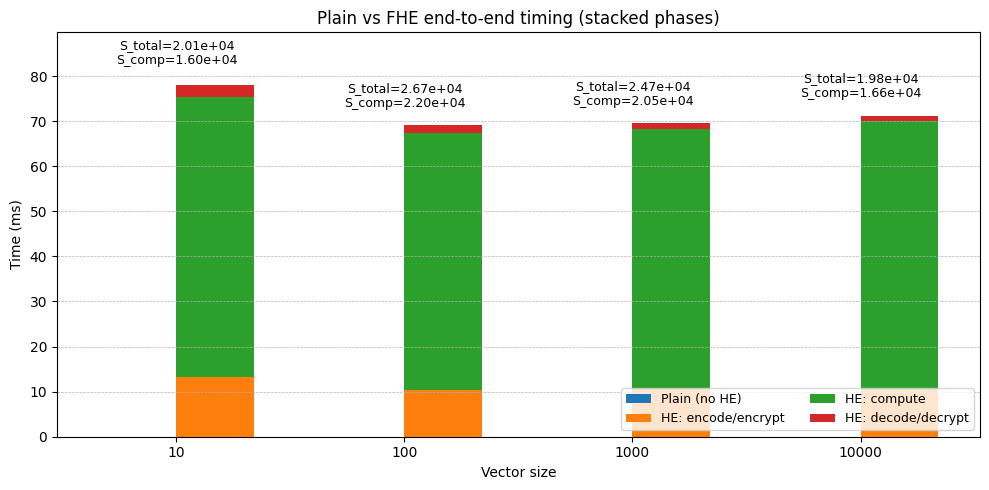

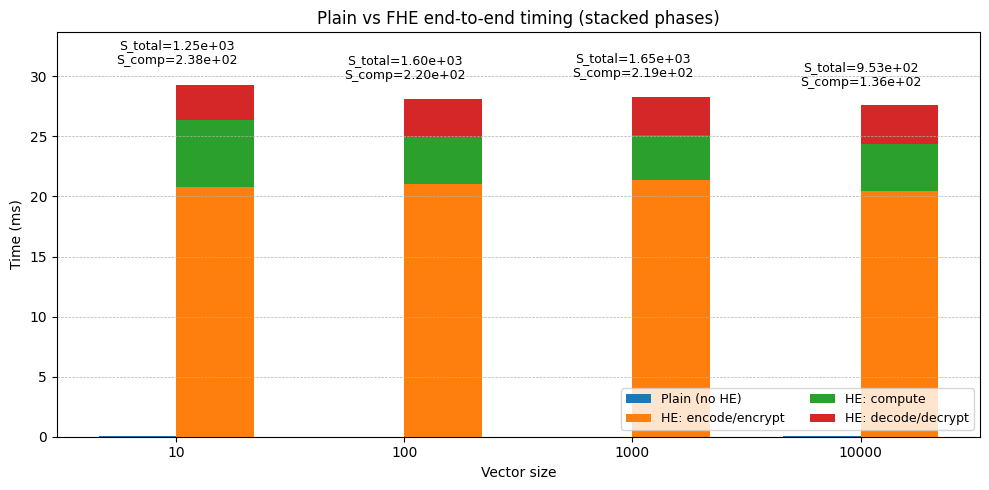

In [3]:
x = np.array([r["vector_size"] for r in vector_size_metrics_regression], dtype=float)
pyfhel_benchmark.print_results(x, vector_size_metrics_regression)
pyfhel_benchmark.print_results(x, vector_size_metrics_vectorop)

performance by degree

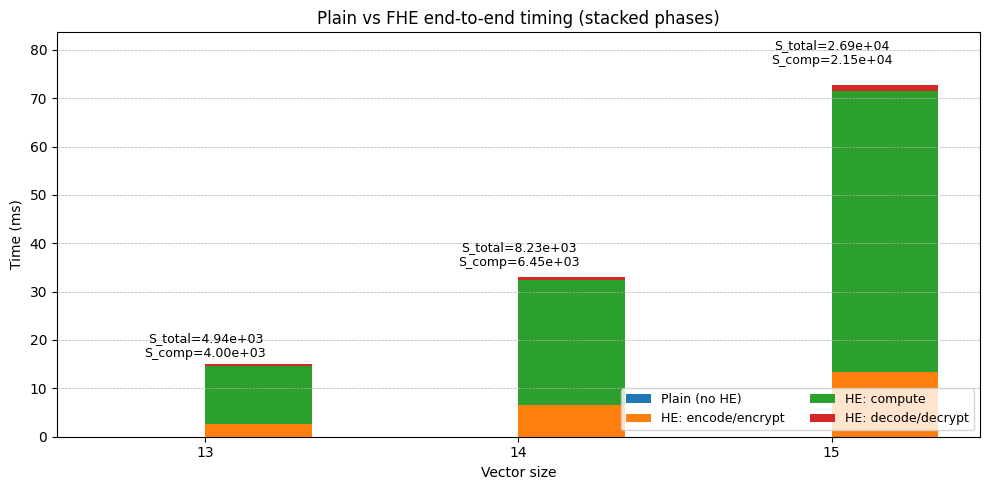

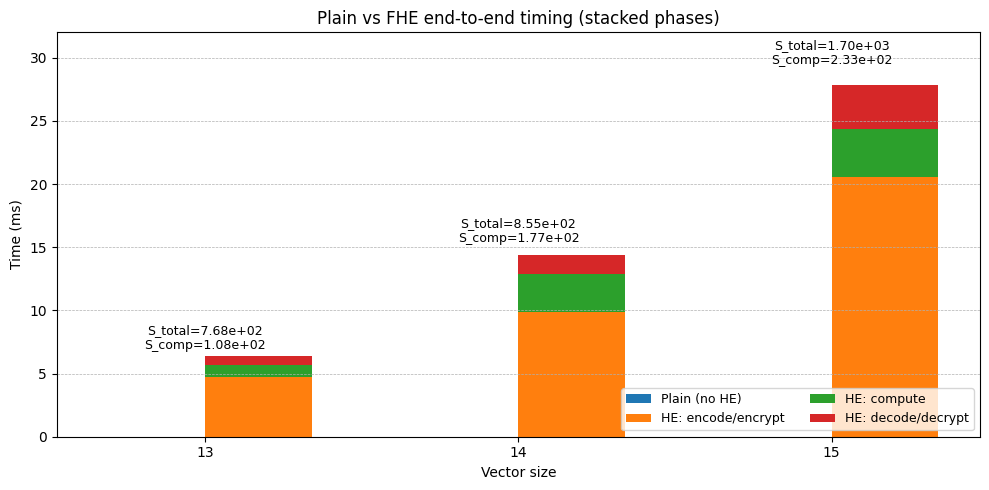

In [4]:
x = np.array([r["degree"] for r in degree_metrics_regression], dtype=float)
pyfhel_benchmark.print_results(x, degree_metrics_regression)
pyfhel_benchmark.print_results(x, degree_metrics_vectorop)

## FC layer test

In [5]:
%%time
fc_test_results = []
for VECTOR_SIZE in [10, 100, 1000]:
    HE = pyfhel_benchmark.init_he(SCHEME, POLY_MOD_DEGREE, SCALE, QI_SIZES)
    layer = pyfhel_benchmark.init_fc_layer_ckks(HE, vector_size=VECTOR_SIZE)
    fc_test_results.append(pyfhel_benchmark.benchmark_fc_layer_ckks(
        HE,
        layer,
        vector_size=VECTOR_SIZE,
        n_tests=3,
        use_activation=False,
    ))

[Test 1/3] MAE = 7.215e-04
[Test 2/3] MAE = 4.987e-04
[Test 3/3] MAE = 4.570e-04

==== FC layer CKKS benchmark summary ====
Vector size: 10
Tests: 3
Avg plain time (ms): 0.025
Avg encrypt time (ms): 12.389
Avg HE compute (ms):654.460
Avg decrypt (ms):12.456
Avg MAE: 5.591e-04
Max MAE: 7.215e-04
Avg normilized MAE: 1.515e-02
Max normilized MAE: 2.104e-02
[Test 1/3] MAE = 5.046e-04
[Test 2/3] MAE = 5.354e-04
[Test 3/3] MAE = 4.745e-04

==== FC layer CKKS benchmark summary ====
Vector size: 100
Tests: 3
Avg plain time (ms): 0.021
Avg encrypt time (ms): 10.338
Avg HE compute (ms):6438.212
Avg decrypt (ms):120.342
Avg MAE: 5.048e-04
Max MAE: 5.354e-04
Avg normilized MAE: 5.613e-02
Max normilized MAE: 1.093e-01
[Test 1/3] MAE = 5.304e-04
[Test 2/3] MAE = 5.339e-04
[Test 3/3] MAE = 5.452e-04

==== FC layer CKKS benchmark summary ====
Vector size: 1000
Tests: 3
Avg plain time (ms): 9.718
Avg encrypt time (ms): 19.258
Avg HE compute (ms):66181.899
Avg decrypt (ms):1242.390
Avg MAE: 5.365e-04
Ma

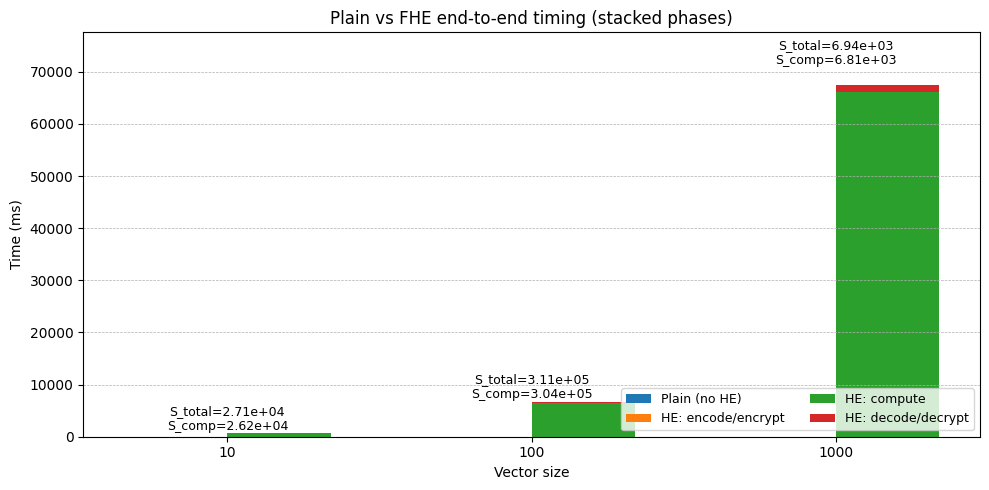

In [6]:
x = np.array([r["vector_size"] for r in fc_test_results], dtype=float)
pyfhel_benchmark.print_results(x, fc_test_results)

In [7]:
%%time
fc_test_results = []
VECTOR_SIZE=100
for degree in [13, 14, 15]:
    POLY_MOD_DEGREE = 2**degree
    HE = pyfhel_benchmark.init_he(SCHEME, POLY_MOD_DEGREE, SCALE, QI_SIZES)
    layer = pyfhel_benchmark.init_fc_layer_ckks(HE, vector_size=VECTOR_SIZE)
    fc_test_results.append(pyfhel_benchmark.benchmark_fc_layer_ckks(
        HE,
        layer,
        vector_size=VECTOR_SIZE,
        n_tests=3,
        use_activation=False,
    ))
    fc_test_results[-1]['degree'] = degree

[Test 1/3] MAE = 4.155e-05
[Test 2/3] MAE = 4.535e-05
[Test 3/3] MAE = 3.962e-05

==== FC layer CKKS benchmark summary ====
Vector size: 100
Tests: 3
Avg plain time (ms): 0.020
Avg encrypt time (ms): 2.546
Avg HE compute (ms):1303.493
Avg decrypt (ms):28.174
Avg MAE: 4.217e-05
Max MAE: 4.535e-05
Avg normilized MAE: 1.921e-03
Max normilized MAE: 3.186e-03
[Test 1/3] MAE = 1.216e-04
[Test 2/3] MAE = 1.104e-04
[Test 3/3] MAE = 1.186e-04

==== FC layer CKKS benchmark summary ====
Vector size: 100
Tests: 3
Avg plain time (ms): 0.020
Avg encrypt time (ms): 5.117
Avg HE compute (ms):2943.383
Avg decrypt (ms):59.229
Avg MAE: 1.169e-04
Max MAE: 1.216e-04
Avg normilized MAE: 1.184e-02
Max normilized MAE: 2.507e-02
[Test 1/3] MAE = 5.656e-04
[Test 2/3] MAE = 4.889e-04
[Test 3/3] MAE = 4.680e-04

==== FC layer CKKS benchmark summary ====
Vector size: 100
Tests: 3
Avg plain time (ms): 0.022
Avg encrypt time (ms): 10.552
Avg HE compute (ms):6683.296
Avg decrypt (ms):126.186
Avg MAE: 5.075e-04
Max MA

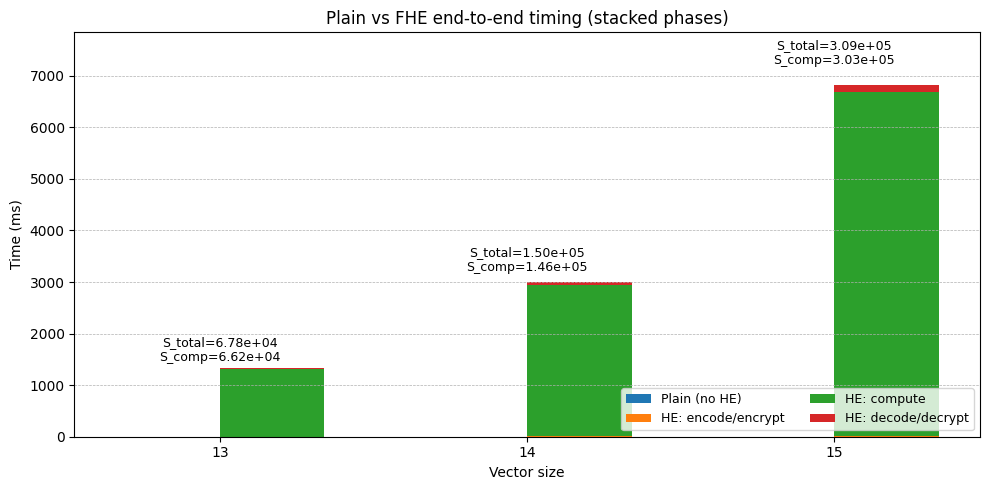

In [8]:
x = np.array([r["degree"] for r in fc_test_results], dtype=float)
pyfhel_benchmark.print_results(x, fc_test_results)

# CNN tests

In [9]:
train_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST('data', train=False, download=True, transform=transforms.ToTensor())

batch_size = 64

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [10]:
class ConvNet(torch.nn.Module):
    def __init__(self, hidden=64, output=10):
        super(ConvNet, self).__init__()        
        self.conv1 = torch.nn.Conv2d(1, 4, kernel_size=7, padding=0, stride=3)
        self.fc1 = torch.nn.Linear(256, hidden)
        self.fc2 = torch.nn.Linear(hidden, output)

    def forward(self, x):
        x = self.conv1(x)
        # square activation function
        x = x * x
        # flattening
        x = x.view(-1, 256)
        x = self.fc1(x)
        x = x * x
        x = self.fc2(x)
        return x


def train(model, train_loader, criterion, optimizer, n_epochs=10):
    # model in training mode
    model.train()
    for epoch in range(1, n_epochs+1):

        train_loss = 0.0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # calculate average losses
        train_loss = train_loss / len(train_loader)

        print('Epoch: {} \tTraining Loss: {:.6f}'.format(epoch, train_loss))
    
    # model in evaluation mode
    model.eval()
    return model


model = ConvNet()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model = train(model, train_loader, criterion, optimizer, 10)

Epoch: 1 	Training Loss: 0.381392
Epoch: 2 	Training Loss: 0.133568
Epoch: 3 	Training Loss: 0.094619
Epoch: 4 	Training Loss: 0.075251
Epoch: 5 	Training Loss: 0.062277
Epoch: 6 	Training Loss: 0.050751
Epoch: 7 	Training Loss: 0.046129
Epoch: 8 	Training Loss: 0.040701
Epoch: 9 	Training Loss: 0.038335
Epoch: 10 	Training Loss: 0.031014


In [11]:
%%time
def test(model, test_loader, criterion):
    # initialize lists to monitor test loss and accuracy
    test_loss = 0.0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    # model in evaluation mode
    model.eval()
    time_total = 0
    for data, target in test_loader:
        t0 = time.time()
        output = model(data)
        dt = time.time() - t0
        print(dt * 1000)
        time_total += dt
        loss = criterion(output, target)
        test_loss += loss.item()
        # convert output probabilities to predicted class
        _, pred = torch.max(output, 1)
        # compare predictions to true label
        correct = np.squeeze(pred.eq(target.data.view_as(pred)))
        # calculate test accuracy for each object class
        for i in range(len(target)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

    # calculate and print avg test loss
    test_loss = test_loss/len(test_loader)
    print(f'Test Loss: {test_loss:.6f}\n')

    for label in range(10):
        print(
            f'Test Accuracy of {label}: {int(100 * class_correct[label] / class_total[label])}% '
            f'({int(np.sum(class_correct[label]))}/{int(np.sum(class_total[label]))})'
        )

    print(
        f'\nTest Accuracy (Overall): {int(100 * np.sum(class_correct) / np.sum(class_total))}% ' 
        f'({int(np.sum(class_correct))}/{int(np.sum(class_total))})'
    )

    print(
        f'\nTime (Overall): {time_total * 1000} '
    )
    
test(model, test_loader, criterion)

0.4203319549560547
0.3790855407714844
0.3135204315185547
0.31757354736328125
0.2884864807128906
0.27060508728027344
0.2837181091308594
0.30541419982910156
0.45371055603027344
0.3123283386230469
0.33211708068847656
0.3578662872314453
0.37288665771484375
0.2856254577636719
0.278472900390625
0.2803802490234375
0.2818107604980469
0.2739429473876953
0.26679039001464844
0.3504753112792969
0.2818107604980469
0.28014183044433594
0.23245811462402344
0.20503997802734375
0.255584716796875
0.1957416534423828
0.3669261932373047
0.2589225769042969
0.20885467529296875
0.23794174194335938
0.19049644470214844
0.17786026000976562
0.18596649169921875
0.1838207244873047
0.18310546875
0.21982192993164062
0.2715587615966797
0.2894401550292969
0.20933151245117188
0.21505355834960938
0.2532005310058594
0.23627281188964844
0.20194053649902344
0.2334117889404297
0.21791458129882812
0.26106834411621094
0.22912025451660156
0.19097328186035156
0.20074844360351562
0.2224445343017578
0.28514862060546875
0.2532005310

## Crypted

In [12]:
class EncConvNet:
    def __init__(self, torch_nn):
        self.conv1_weight = torch_nn.conv1.weight.data.view(
            torch_nn.conv1.out_channels, torch_nn.conv1.kernel_size[0],
            torch_nn.conv1.kernel_size[1]
        ).tolist()
        self.conv1_bias = torch_nn.conv1.bias.data.tolist()
        
        self.fc1_weight = torch_nn.fc1.weight.T.data.tolist()
        self.fc1_bias = torch_nn.fc1.bias.data.tolist()
        
        self.fc2_weight = torch_nn.fc2.weight.T.data.tolist()
        self.fc2_bias = torch_nn.fc2.bias.data.tolist()
        
        
    def forward(self, enc_x, windows_nb):
        # conv layer
        enc_channels = []
        for kernel, bias in zip(self.conv1_weight, self.conv1_bias):
            y = enc_x.conv2d_im2col(kernel, windows_nb) + bias
            enc_channels.append(y)
        # pack all channels into a single flattened vector
        enc_x = ts.CKKSVector.pack_vectors(enc_channels)
        # square activation
        enc_x.square_()
        # fc1 layer
        enc_x = enc_x.mm(self.fc1_weight) + self.fc1_bias
        # square activation
        enc_x.square_()
        # fc2 layer
        enc_x = enc_x.mm(self.fc2_weight) + self.fc2_bias
        return enc_x
    
    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

In [13]:

def enc_test(context, model, test_loader, criterion, kernel_shape, stride):
    # initialize lists to monitor test loss and accuracy
    test_loss = 0.0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))
    enc_total = 0
    comp_total = 0
    dec_total = 0
    for data, target in test_loader:
        # Encoding and encryption
        t0 = time.time()
        x_enc, windows_nb = ts.im2col_encoding(
            context, data.view(28, 28).tolist(), kernel_shape[0],
            kernel_shape[1], stride
        )
        enc_time = time.time() - t0
        # Encrypted evaluation
        t0 = time.time()
        enc_output = enc_model(x_enc, windows_nb)
        comp_time = time.time() - t0
        # Decryption of result
        t0 = time.time()
        output = enc_output.decrypt()
        decoding_time = time.time() - t0
        print(enc_time * 1000, comp_time * 1000, decoding_time * 1000)
        enc_total += enc_time
        comp_total += comp_time
        dec_total += decoding_time
        output = torch.tensor(output).view(1, -1)
        # compute loss
        loss = criterion(output, target)
        test_loss += loss.item()
        
        # convert output probabilities to predicted class
        _, pred = torch.max(output, 1)
        # compare predictions to true label
        correct = np.squeeze(pred.eq(target.data.view_as(pred)))
        # calculate test accuracy for each object class
        label = target.data[0]
        class_correct[label] += correct.item()
        class_total[label] += 1


    # calculate and print avg test loss
    test_loss = test_loss / sum(class_total)
    print(f'Test Loss: {test_loss:.6f}\n')

    for label in range(10):
        print(
            f'Test Accuracy of {label}: {int(100 * class_correct[label] / class_total[label])}% '
            f'({int(np.sum(class_correct[label]))}/{int(np.sum(class_total[label]))})'
        )

    print(
        f'\nTest Accuracy (Overall): {int(100 * np.sum(class_correct) / np.sum(class_total))}% ' 
        f'({int(np.sum(class_correct))}/{int(np.sum(class_total))})'
    )

    print(
        f'\nEncoding Time (Overall): {enc_total * 1000} '
    )

    print(
        f'\nCompute Time (Overall): {comp_total * 1000} '
    )

    print(
        f'\nDecoding Time (Overall): {dec_total * 1000} '
    )

In [14]:
# Load one element at a time
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
# required for encoding
kernel_shape = model.conv1.kernel_size
stride = model.conv1.stride[0]

bits_scale = 26

# Create TenSEAL context
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[31, bits_scale, bits_scale, bits_scale, bits_scale, bits_scale, bits_scale, 31]
)

# set the scale
context.global_scale = pow(2, bits_scale)

# galois keys are required to do ciphertext rotations
context.generate_galois_keys()


In [15]:
from torch.utils.data import Subset, DataLoader

test_dataset = test_loader.dataset
indices = list(range(100))
test_subset = Subset(test_dataset, indices)

test_loader_small = DataLoader(
    test_subset,
    batch_size=1,
    shuffle=False
)

In [16]:
%%time
enc_model = EncConvNet(model)
enc_test(context, enc_model, test_loader, criterion, kernel_shape, stride)

5.433797836303711 362.77294158935547 0.5121231079101562
4.8542022705078125 355.2236557006836 0.5354881286621094
4.90570068359375 352.7789115905762 0.2486705780029297
4.858970642089844 350.543737411499 0.3268718719482422
4.98509407043457 366.5008544921875 0.31685829162597656
4.866838455200195 366.78528785705566 0.28228759765625
4.818439483642578 355.6358814239502 0.40435791015625
4.970788955688477 355.0846576690674 0.41866302490234375
4.881381988525391 359.5597743988037 0.2613067626953125
4.912376403808594 347.56016731262207 0.2689361572265625
4.840612411499023 355.1898002624512 0.31256675720214844
4.754781723022461 356.65202140808105 0.3795623779296875
4.998922348022461 354.724645614624 0.3304481506347656
4.884958267211914 349.4114875793457 0.2999305725097656
4.996538162231445 347.395658493042 0.3147125244140625
5.005836486816406 351.98426246643066 0.2961158752441406
4.845619201660156 353.64365577697754 0.31566619873046875
6.718873977661133 367.0637607574463 0.38552284240722656
4.82678